In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:

# 1. Load Data
df = pd.read_csv("./data/df_features.csv")
df['trading_date'] = pd.to_datetime(df['trading_date'])
df = df.sort_values('trading_date').reset_index(drop=True)

In [82]:
df = df[(df['trading_date'] > '2019-04-30') & (df['trading_date'] < '2026-03-26')].reset_index(drop=True).copy()

In [83]:
# 3. Define Features and Target
cols_to_drop = [
    'trading_date', 'target_vol_21d'
]
features = [c for c in df.columns if c not in cols_to_drop]
target = 'target_vol_21d'

In [84]:
split_idx = int(len(df) * 0.85)

train_df = df.loc[:split_idx].copy()
test_df = df.loc[split_idx+1:].copy()

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"Training on {len(train_df)} days. Testing on {len(test_df)} days.")

Training on 1475 days. Testing on 260 days.


In [60]:
train_df['prepped_sentiment'].describe()

count    1475.000000
mean        0.404392
std         0.081450
min         0.283918
25%         0.344729
50%         0.383939
75%         0.471877
max         0.540660
Name: prepped_sentiment, dtype: float64

In [101]:
train_df.columns

Index(['trading_date', 'msft_return', 'roa', 'cash_coverage', 'debt_to_asset',
       'fcf_margin', 'net_income_qoq', 'sec_sentiment', 'sec_neutral',
       'sec_dispersion', 'prepped_sentiment', 'prepped_dispersion',
       'prepped_neutral', 'qa_sentiment', 'qa_dispersion', 'qa_neutral',
       'days_since_earnings', 'days_since_filing', 'qqq_return', 'spy_return',
       'msft_vs_tech', 'msft_vs_market', 'vix_level', 'vix_5d_trend',
       'yield_10y_level', 'yield_10y_delta_5d', 'vol_rolling_21d',
       'qqq_vol_21d', 'vol_garman_klass', 'vol_surge', 'amihud_ratio',
       'dist_from_ma200', 'target_vol_21d'],
      dtype='str')

In [ ]:
feature_groups = {
    "Price_dynamics": ['vol_rolling_21d', 'msft_return', 'dist_from_ma200' ,'vol_garman_klass', 'amihud_ratio', 'msft_vs_market_alpha', 'msft_vs_tech_alpha'],
    "Market": ['vix_level', 'vix_5d_trend', 'yield_10y_level', 'yield_10y_delta_5d'],
    "NLP_Sentiment": ['prepped_sentiment', 'days_since_earnings', 'qa_dispersion', 'sec_sentiment'],
    "Fundamentals": ['roa', 'debt_to_asset', 'fcf_margin', 'ni_growth_qoq', 'cash_coverage']
}

# Example: Run a correlation matrix just for the NLP group
# sns.heatmap(train_df[feature_groups['NLP_Sentiment'] + ['target_vol_21d']].corr(method='spearman'), annot=True)

🚀 Running Categorical EDA Pipeline...

📈 Analyzing Continuous Daily Features (Price & Macro)...


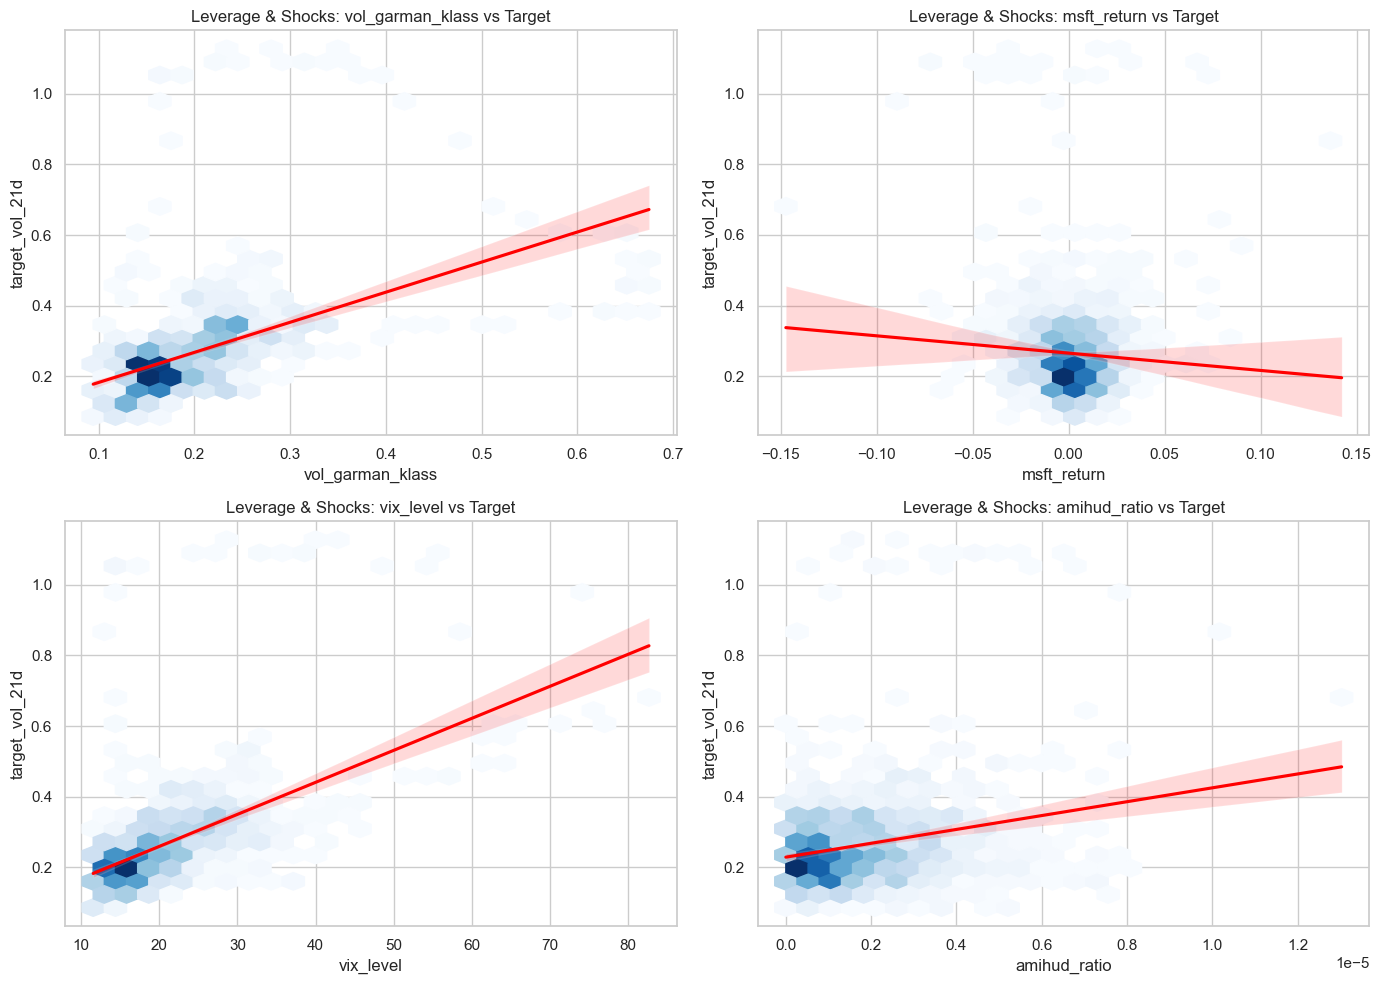


📊 Analyzing Step-Function Features (NLP & Fundamentals)...


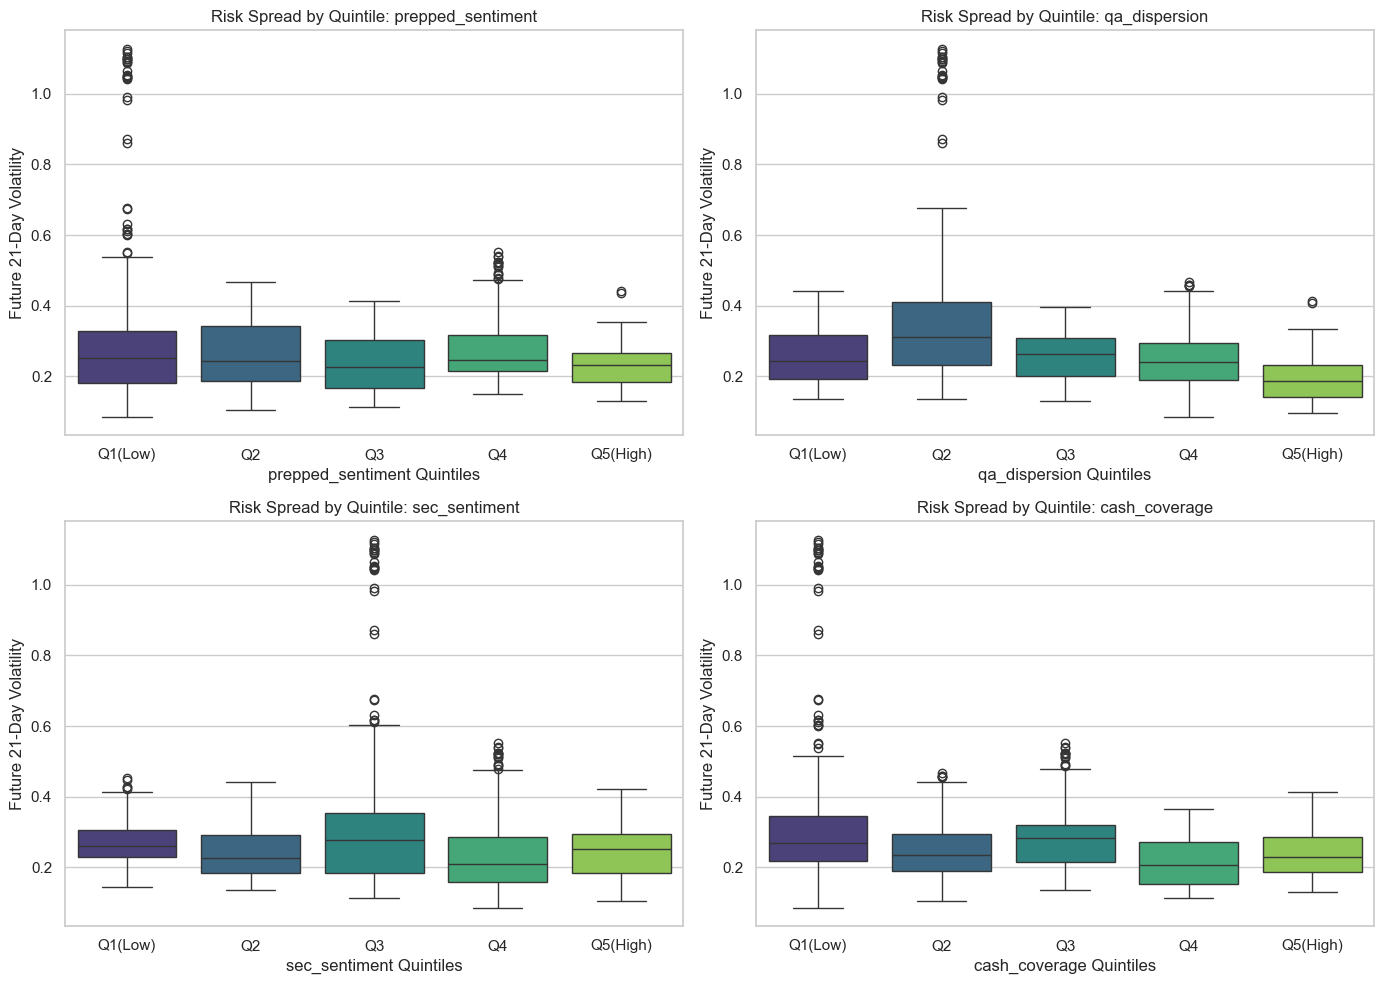


⏳ Analyzing Information Decay (Temporal Clock)...


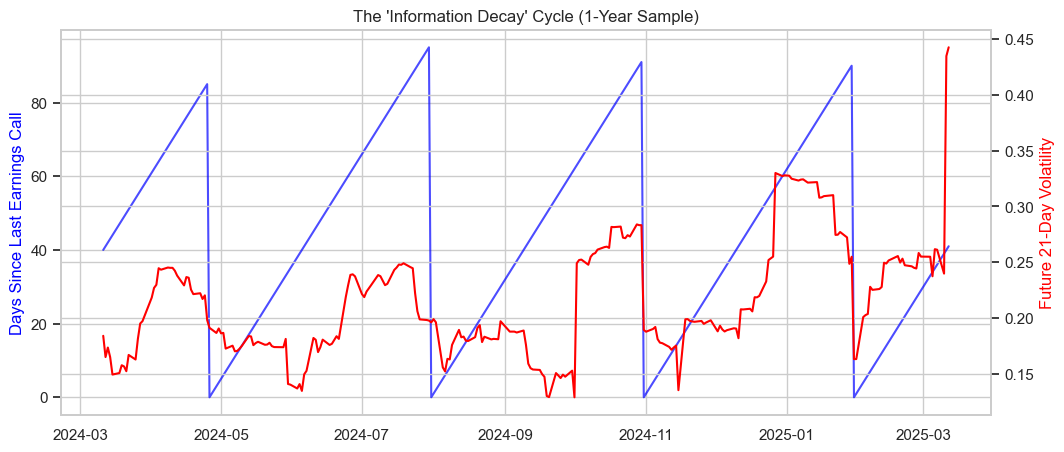

In [102]:


print("🚀 Running Categorical EDA Pipeline...")

# 1. The Taxonomy Dictionary
feature_groups = {
    "Price_Action_and_Dynamics": ['vol_rolling_21d', 'msft_return', 'dist_from_ma200', 'vol_garman_klass', 'amihud_ratio', 'msft_vs_market_alpha', 'msft_vs_tech_alpha'],
    "Macro_Regime": ['vix_level', 'vix_5d_trend', 'yield_10y_level', 'yield_10y_delta_5d'],
    "NLP_Sentiment": ['prepped_sentiment', 'qa_dispersion', 'sec_sentiment'],
    "Fundamental_Accounting": ['roa', 'debt_to_asset', 'fcf_margin', 'ni_growth_qoq', 'cash_coverage'],
    "Temporal_Decay": ['days_since_earnings', 'days_since_filing']
}

target = 'target_vol_21d'
sns.set_theme(style="whitegrid")

# ==========================================
# ANALYSIS 1: CONTINUOUS FEATURES (Price & Macro)
# Tool: Hexbin Scatter Plots with Regression Lines
# ==========================================
print("\n📈 Analyzing Continuous Daily Features (Price & Macro)...")
continuous_features = feature_groups["Price_Action_and_Dynamics"] + feature_groups["Macro_Regime"]

# Let's just plot the top 4 most important continuous ones to save space
top_continuous = ['vol_garman_klass', 'msft_return', 'vix_level', 'amihud_ratio']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(top_continuous):
    ax = axes[i]
    # Hexbin handles dense financial data much better than raw scatter dots
    ax.hexbin(train_df[feature], train_df[target], gridsize=25, cmap='Blues', mincnt=1)
    sns.regplot(data=train_df, x=feature, y=target, scatter=False, color='red', ax=ax)
    ax.set_title(f"Leverage & Shocks: {feature} vs Target")

plt.tight_layout()
plt.show()

# ==========================================
# ANALYSIS 2: STEP-FUNCTION FEATURES (NLP & Fundamentals)
# Tool: Quintile Spread Boxplots
# ==========================================
print("\n📊 Analyzing Step-Function Features (NLP & Fundamentals)...")
step_features = feature_groups["NLP_Sentiment"] + feature_groups["Fundamental_Accounting"]

# We will look at the Big Three NLP + Cash Coverage
top_step = ['prepped_sentiment', 'qa_dispersion', 'sec_sentiment', 'cash_coverage']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(top_step):
    ax = axes[i]
    # Create 5 buckets (Quintiles) to see if risk steps up linearly
    # Using 'rank' method to handle many identical forward-filled values
    train_df['temp_quintile'] = pd.qcut(train_df[feature].rank(method='first'), q=5, labels=['Q1(Low)', 'Q2', 'Q3', 'Q4', 'Q5(High)'])
    
    sns.boxplot(data=train_df, x='temp_quintile', y=target, palette='viridis', ax=ax)
    ax.set_title(f"Risk Spread by Quintile: {feature}")
    ax.set_xlabel(f"{feature} Quintiles")
    ax.set_ylabel("Future 21-Day Volatility")

train_df.drop(columns=['temp_quintile'], inplace=True)
plt.tight_layout()
plt.show()

# ==========================================
# ANALYSIS 3: THE TEMPORAL CLOCK
# Tool: Dual-Axis Time Series
# ==========================================
print("\n⏳ Analyzing Information Decay (Temporal Clock)...")

# Take a 1-year slice (roughly 252 trading days) to see the pattern clearly
slice_df = train_df.tail(252) 

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(slice_df['trading_date'], slice_df['days_since_earnings'], color='blue', alpha=0.7, label='Days Since Earnings')
ax2.plot(slice_df['trading_date'], slice_df[target], color='red', linewidth=1.5, label='Future Volatility')

ax1.set_ylabel('Days Since Last Earnings Call', color='blue')
ax2.set_ylabel('Future 21-Day Volatility', color='red')
plt.title("The 'Information Decay' Cycle (1-Year Sample)")
plt.show()

🚀 Running Advanced Multivariate EDA...
Generating Macro vs Micro Regime Matrix...


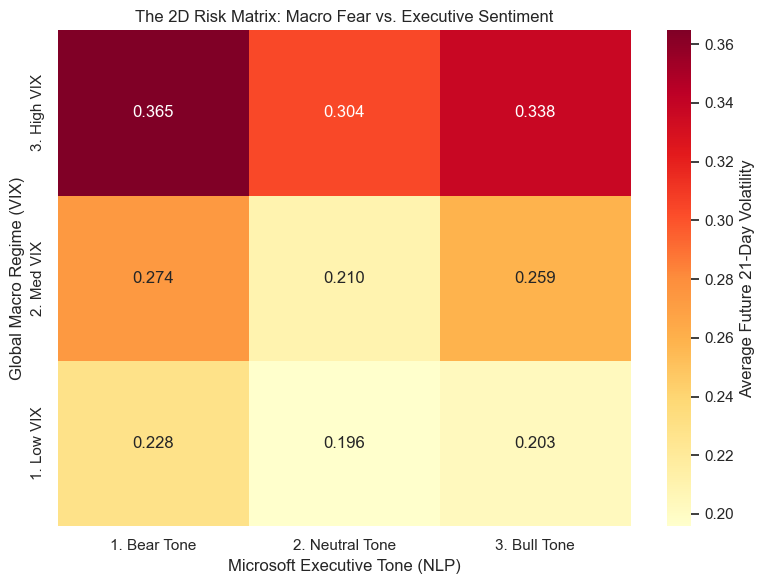


Generating Non-Linear Topographical Contour Map...


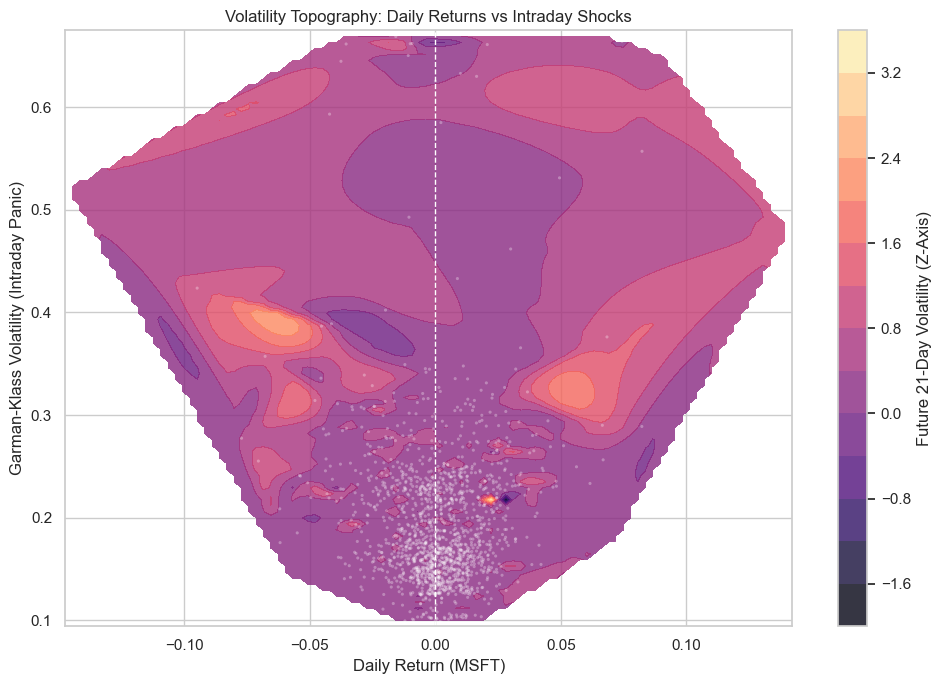

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import griddata

print("🚀 Running Advanced Multivariate EDA...")

# ==========================================
# TECHNIQUE 1: THE 2D REGIME MATRIX
# ==========================================
print("Generating Macro vs Micro Regime Matrix...")

# 1. Create 33rd and 66th percentile bins (Low, Medium, High)
train_df['macro_vix_regime'] = pd.qcut(train_df['vix_level'], q=3, labels=['1. Low VIX', '2. Med VIX', '3. High VIX'])
train_df['micro_sent_regime'] = pd.qcut(train_df['prepped_sentiment'].rank(method='first'), q=3, labels=['1. Bear Tone', '2. Neutral Tone', '3. Bull Tone'])

# 2. Build the Pivot Table (Calculate average target volatility for each intersection)
regime_matrix = pd.pivot_table(
    train_df, 
    values='target_vol_21d', 
    index='macro_vix_regime', 
    columns='micro_sent_regime', 
    aggfunc=np.mean
)

# 3. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(regime_matrix, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={'label': 'Average Future 21-Day Volatility'})
plt.title("The 2D Risk Matrix: Macro Fear vs. Executive Sentiment")
plt.xlabel("Microsoft Executive Tone (NLP)")
plt.ylabel("Global Macro Regime (VIX)")
plt.gca().invert_yaxis() # Put High VIX at the top for intuitive reading
plt.tight_layout()
plt.show()

# Cleanup
train_df.drop(columns=['macro_vix_regime', 'micro_sent_regime'], inplace=True)

# ==========================================
# TECHNIQUE 2: THE VOLATILITY CONTOUR MAP
# ==========================================
print("\nGenerating Non-Linear Topographical Contour Map...")

# 1. Define X, Y, and Z
x = train_df['msft_return'].values
y = train_df['vol_garman_klass'].values
z = train_df['target_vol_21d'].values

# 2. Create a standardized grid
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
xi, yi = np.meshgrid(xi, yi)

# 3. Interpolate Z values onto the grid using cubic interpolation
zi = griddata((x, y), z, (xi, yi), method='cubic')

# 4. Plot the Contour Surface
plt.figure(figsize=(10, 7))
contour = plt.contourf(xi, yi, zi, levels=15, cmap='magma', alpha=0.8)
plt.colorbar(contour, label='Future 21-Day Volatility (Z-Axis)')

# Overlay the actual scatter points faintly to show where the data lives
plt.scatter(x, y, c='white', s=5, alpha=0.3, edgecolors='none')

plt.axvline(0, color='white', linestyle='--', linewidth=1)
plt.title("Volatility Topography: Daily Returns vs Intraday Shocks")
plt.xlabel("Daily Return (MSFT)")
plt.ylabel("Garman-Klass Volatility (Intraday Panic)")
plt.tight_layout()
plt.show()

🔍 Deep Dive EDA on Top Features...


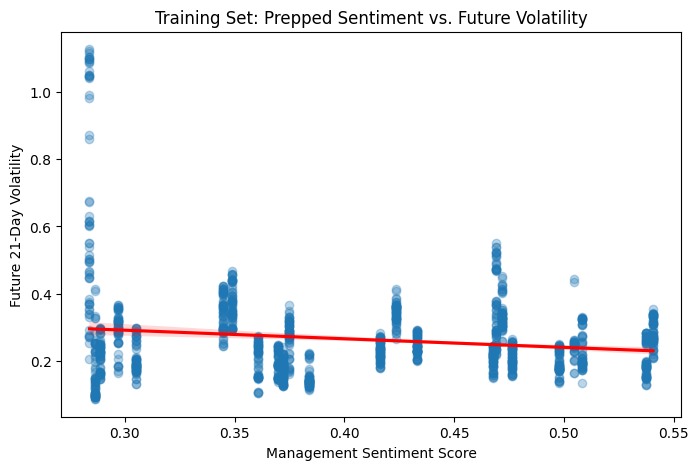

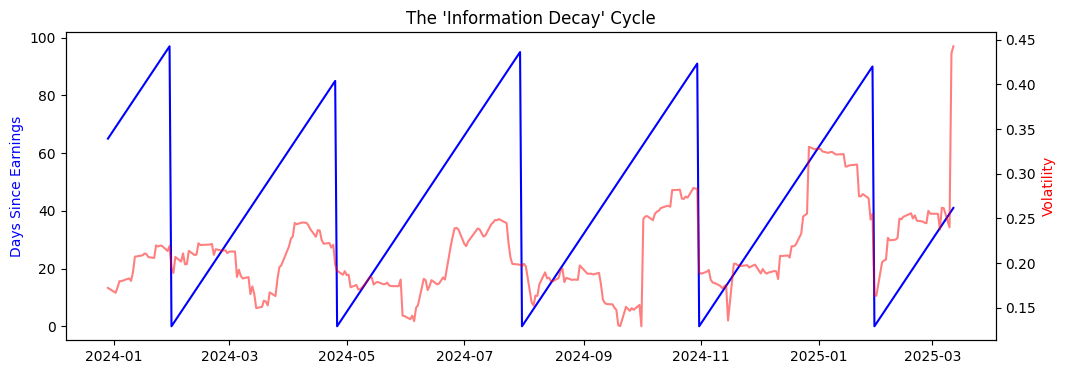

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# We use train_df so we have access to BOTH the feature and the target/dates
print("🔍 Deep Dive EDA on Top Features...")

# 1. How does Sentiment affect Volatility? (Scatter Plot)
plt.figure(figsize=(8, 5))
sns.regplot(
    data=train_df, 
    x='prepped_sentiment', 
    y='target_vol_21d', 
    scatter_kws={'alpha':0.3}, 
    line_kws={'color':'red'}
)
plt.title("Training Set: Prepped Sentiment vs. Future Volatility")
plt.xlabel("Management Sentiment Score")
plt.ylabel("Future 21-Day Volatility")
plt.show()

# 2. How does 'Days Since Earnings' act over time? (Time Series)
# We plot a small slice (e.g., first 300 days) so we can see the "sawtooth" pattern
slice_df = train_df.tail(300)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.plot(slice_df['trading_date'], slice_df['days_since_earnings'], color='blue', label='Days Since Earnings')
ax2.plot(slice_df['trading_date'], slice_df['target_vol_21d'], color='red', alpha=0.5, label='Volatility')

ax1.set_ylabel('Days Since Earnings', color='blue')
ax2.set_ylabel('Volatility', color='red')
plt.title("The 'Information Decay' Cycle")
plt.show()

In [99]:
train_df.columns

Index(['trading_date', 'msft_return', 'roa', 'cash_coverage', 'debt_to_asset',
       'fcf_margin', 'net_income_qoq', 'sec_sentiment', 'sec_neutral',
       'sec_dispersion', 'prepped_sentiment', 'prepped_dispersion',
       'prepped_neutral', 'qa_sentiment', 'qa_dispersion', 'qa_neutral',
       'days_since_earnings', 'days_since_filing', 'qqq_return', 'spy_return',
       'msft_vs_tech', 'msft_vs_market', 'vix_level', 'vix_5d_trend',
       'yield_10y_level', 'yield_10y_delta_5d', 'vol_rolling_21d',
       'qqq_vol_21d', 'vol_garman_klass', 'vol_surge', 'amihud_ratio',
       'dist_from_ma200', 'target_vol_21d'],
      dtype='str')

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")


num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

# ---------- Tables ----------
missing = (
    train_df.isna().mean()
    .sort_values(ascending=False)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "column"})
)
missing["missing_count"] = train_df.isna().sum().values
missing["dtype"] = missing["column"].map(train_df.dtypes.astype(str))
missing.to_csv("./output/eda/eda_missingness.csv", index=False)

summary = train_df[num_cols].describe().T
summary["missing_pct"] = train_df[num_cols].isna().mean()
summary["skew"] = train_df[num_cols].skew(numeric_only=True)
summary["kurtosis"] = train_df[num_cols].kurt(numeric_only=True)
summary.to_csv("./output/eda/eda_numeric_summary.csv")

corr_target = train_df[num_cols].corr(numeric_only=True)["target_vol_21d"].sort_values(ascending=False)
corr_target.to_csv("./output/eda/eda_corr_with_target.csv")

# ---------- Feature set for correlation ----------
key_features = [
    "target_vol_21d",
    "vix_level",
    "vol_rolling_21d",
    "qqq_vol_21d",
    "vol_garman_klass",
    "vol_surge",
    "dist_from_ma200",
    "yield_10y_level",
    "yield_10y_delta_5d",
    "sec_sentiment",
    "sec_neutral",
    "sec_dispersion",
    "prepped_sentiment",
    "prepped_neutral",
    "prepped_dispersion",
    "qa_sentiment",
    "qa_neutral",
    "qa_dispersion",
    "days_since_earnings",
    "days_since_filing",
    "amihud_ratio",
    "msft_vs_tech",
    "msft_vs_market",
]
key_features = [c for c in key_features if c in train_df.columns]


# ---------- Plot 2: Target distribution ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_df["target_vol_21d"].dropna(), bins=40, kde=True, ax=axes[0], color="purple")
axes[0].set_title("Target Distribution: 21-Day Forward Volatility")
axes[0].set_xlabel("target_vol_21d")

sns.boxplot(x=train_df["target_vol_21d"], ax=axes[1], color="purple")
axes[1].set_title("Target Boxplot")
axes[1].set_xlabel("target_vol_21d")
plt.tight_layout()
fig.savefig("./output/eda/eda_target_distribution.png", dpi=180, bbox_inches="tight")
plt.close(fig)

# ---------- Plot 3: Target over time ----------
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_df["trading_date"], train_df["target_vol_21d"], color="purple", linewidth=1)
ax.set_title("21-Day Forward Volatility Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("target_vol_21d")
plt.tight_layout()
fig.savefig("./output/eda/eda_target_timeseries.png", dpi=180, bbox_inches="tight")
plt.close(fig)

# ---------- Plot 4: Correlation heatmap ----------
corr = train_df[key_features].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Heatmap: Key Features")
plt.tight_layout()
fig.savefig("./output/eda/eda_corr_heatmap.png", dpi=180, bbox_inches="tight")
plt.close(fig)

# ---------- Plot 5: Scatter vs target ----------
scatter_feats = [
    c for c in [
        "vix_level",
        "vol_rolling_21d",
        "qqq_vol_21d",
        "vol_garman_klass",
        "dist_from_ma200",
        "sec_sentiment",
        "prepped_sentiment",
        "qa_sentiment",
        "cash_coverage"
    ] if c in train_df.columns
]
all_feats = train_df.drop(columns=["trading_date", "target_vol_21d"]).columns.tolist()
if all_feats:
    n = len(all_feats)
    cols = 2
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i, feat in enumerate(all_feats):
        sns.regplot(
            data=train_df,
            x=feat,
            y="target_vol_21d",
            ax=axes[i],
            scatter_kws={"s": 10, "alpha": 0.35},
            line_kws={"color": "red"},
        )
        axes[i].set_title(f"{feat} vs target_vol_21d")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    fig.savefig("./output/eda/eda_scatter_vs_target.png", dpi=180, bbox_inches="tight")
    plt.close(fig)

# ---------- Plot 6: Sentiment over time ----------
sent_feats = [c for c in ["sec_sentiment", "prepped_sentiment", "qa_sentiment"] if c in train_df.columns]
if sent_feats:
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ["#4C78A8", "#F58518", "#E45756"]
    for feat, color in zip(sent_feats, colors):
        ax.plot(train_df["trading_date"], train_df[feat], label=feat, linewidth=1, alpha=0.9, color=color)
    ax.set_title("Sentiment Features Over Time")
    ax.set_xlabel("Date")
    ax.legend()
    plt.tight_layout()
    fig.savefig("./output/eda/eda_sentiment_timeseries.png", dpi=180, bbox_inches="tight")
    plt.close(fig)

# ---------- Plot 7: Days since earnings ----------
if "days_since_earnings" in train_df.columns:
    tmp = train_df[["days_since_earnings", "target_vol_21d"]].dropna().copy()
    tmp = tmp[tmp["days_since_earnings"] < 120]

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.lineplot(data=tmp, x="days_since_earnings", y="target_vol_21d", errorbar=None, ax=ax, color="#54A24B")
    ax.set_title("Average 21-Day Forward Volatility by Days Since Earnings")
    ax.set_xlabel("Days Since Earnings")
    ax.set_ylabel("target_vol_21d")
    plt.tight_layout()
    fig.savefig("./output/eda/eda_days_since_earnings.png", dpi=180, bbox_inches="tight")
    plt.close(fig)

# ---------- Plot 8: Market regime scatter ----------
reg_feats = [c for c in ["vix_level", "vol_rolling_21d", "qqq_vol_21d"] if c in train_df.columns]
if reg_feats:
    fig, axes = plt.subplots(1, len(reg_feats), figsize=(6 * len(reg_feats), 5))
    if len(reg_feats) == 1:
        axes = [axes]

    for ax, feat in zip(axes, reg_feats):
        sns.scatterplot(data=train_df, x=feat, y="target_vol_21d", alpha=0.25, s=18, ax=ax)
        sns.regplot(data=train_df, x=feat, y="target_vol_21d", scatter=False, ax=ax, color="red")
        ax.set_title(f"{feat} vs target_vol_21d")

    plt.tight_layout()
    fig.savefig("./output/eda/eda_regime_scatter.png", dpi=180, bbox_inches="tight")
    plt.close(fig)

# ---------- Plot 9: Rolling target mean ----------
fig, ax = plt.subplots(figsize=(14, 5))
roll = train_df["target_vol_21d"].rolling(21, min_periods=10).mean()
ax.plot(train_df["trading_date"], train_df["target_vol_21d"], color="lightgray", linewidth=0.8, label="Daily")
ax.plot(train_df["trading_date"], roll, color="#4C78A8", linewidth=2, label="21D Rolling Mean")
ax.set_title("Target Volatility with 21-Day Rolling Mean")
ax.legend()
plt.tight_layout()
fig.savefig("./output/eda/eda_target_rollmean.png", dpi=180, bbox_inches="tight")
plt.close(fig)

print("Saved CSVs and PNGs to output/")
print(train_df.shape)
print(corr_target.head(10))

Saved CSVs and PNGs to output/
(1475, 33)
target_vol_21d      1.000000
vix_level           0.544720
vol_garman_klass    0.485905
vol_rolling_21d     0.472222
qqq_vol_21d         0.447491
vix_5d_trend        0.246257
amihud_ratio        0.230910
prepped_neutral     0.151443
debt_to_asset       0.133999
vol_surge           0.110692
Name: target_vol_21d, dtype: float64


🚀 Initiating Exhaustive Quantitative EDA on Training Data...

📊 PILLAR 1: Target Variable Dynamics


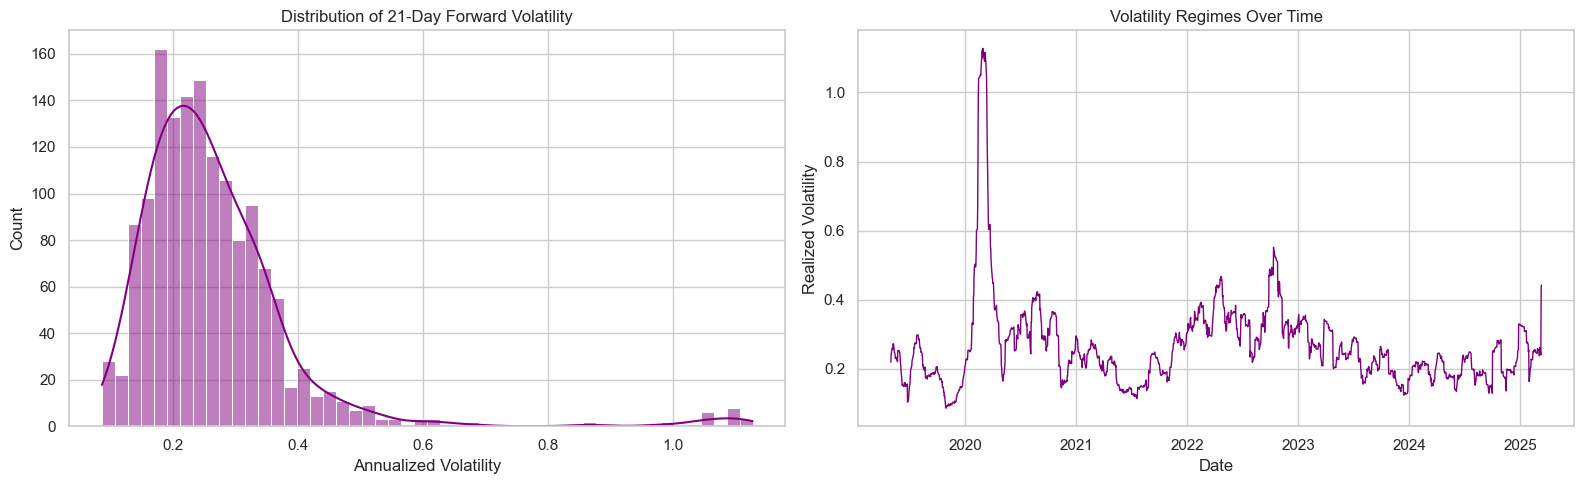


📈 PILLAR 2: Feature vs. Target Relationships


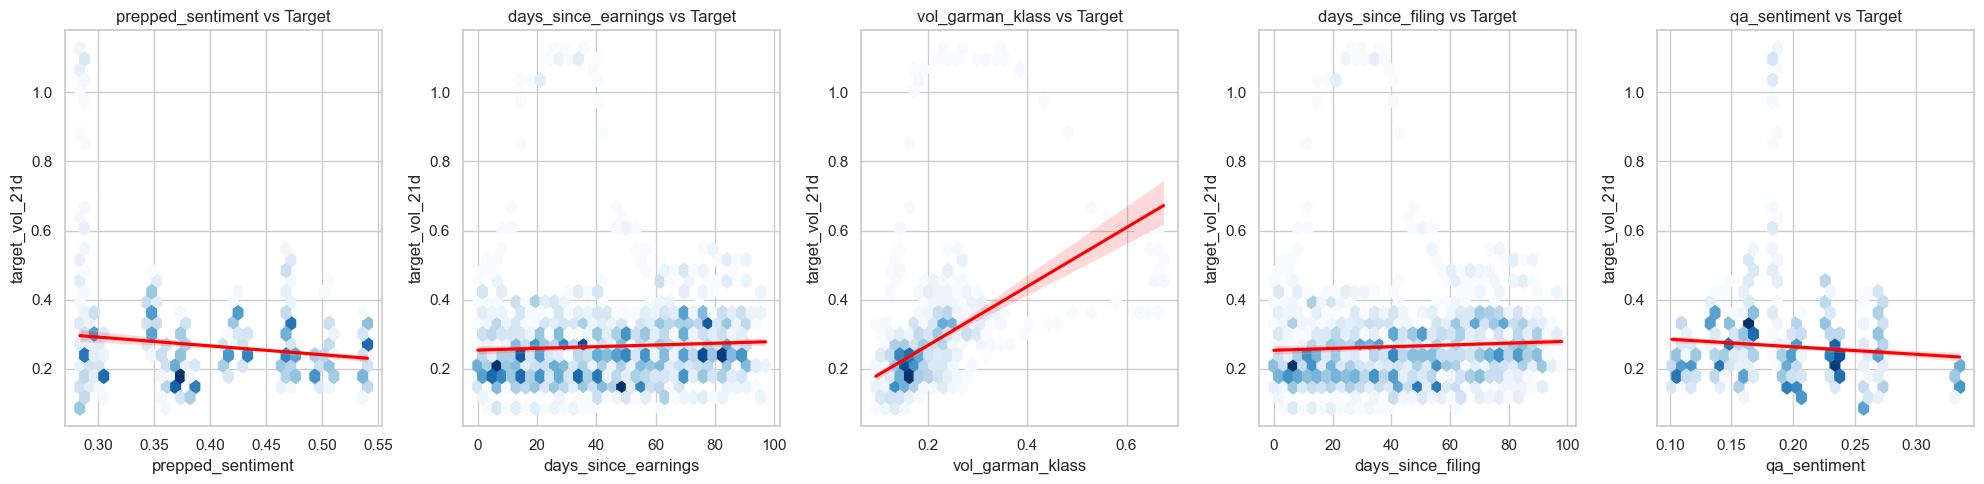


🧩 PILLAR 3: Feature Correlation Matrix (Spearman)


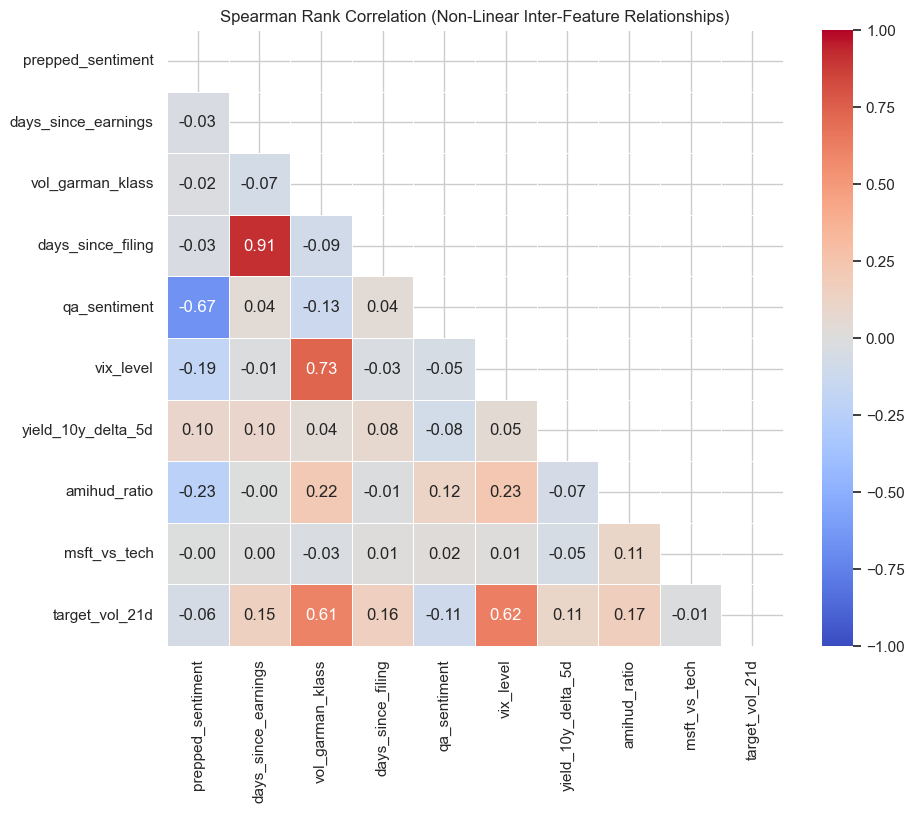


⏳ PILLAR 4: Temporal Stability of Alpha


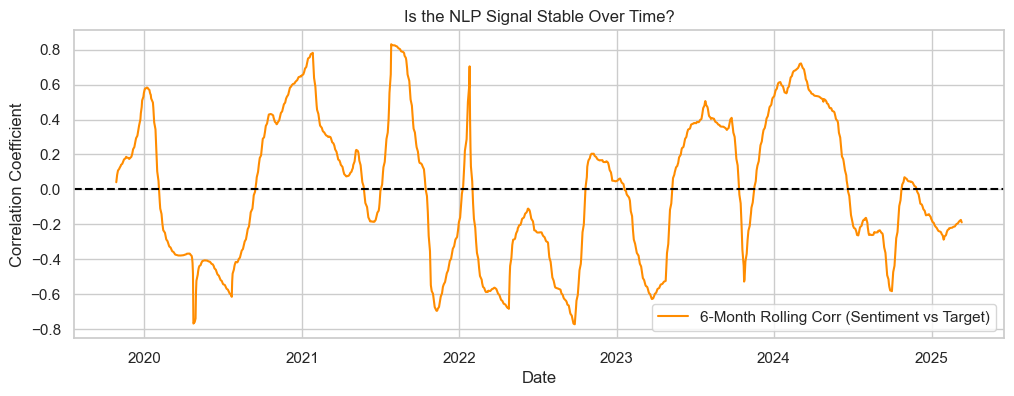


📊 PILLAR 5: Quintile Spread Analysis


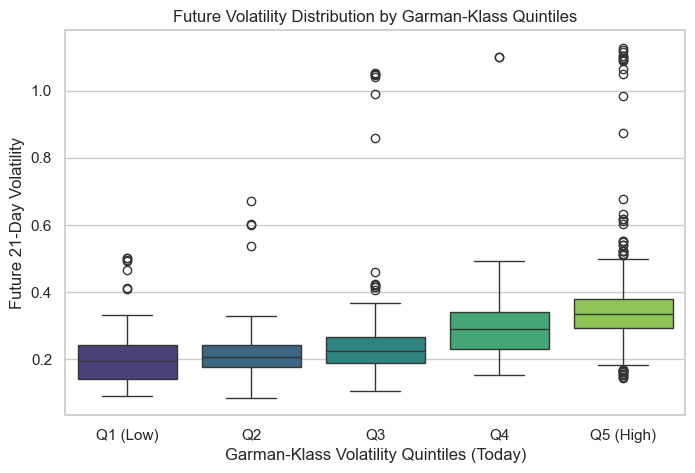

✅ EDA Complete.


In [96]:
import warnings
warnings.filterwarnings('ignore')

print("🚀 Initiating Exhaustive Quantitative EDA on Training Data...")

# Ensure dates are datetime objects and sort
train_df['trading_date'] = pd.to_datetime(train_df['trading_date'])
train_df = train_df.sort_values('trading_date')

# Define our core feature groups for targeted analysis
target = 'target_vol_21d'
core_alphas = ['prepped_sentiment', 'days_since_earnings', 'vol_garman_klass','days_since_filing','qa_sentiment']
macro_liquidity = ['vix_level', 'yield_10y_delta_5d', 'amihud_ratio', 'msft_vs_tech']

# Set aesthetic style
sns.set_theme(style="whitegrid", palette="muted")

# ==========================================
# PILLAR 1: TARGET VARIABLE DYNAMICS
# ==========================================
print("\n📊 PILLAR 1: Target Variable Dynamics")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1A: Distribution (Looking for skewness and fat tails)
sns.histplot(train_df[target], bins=50, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribution of 21-Day Forward Volatility')
axes[0].set_xlabel('Annualized Volatility')

# 1B: Time Series (Looking for regime shifts and clustering)
axes[1].plot(train_df['trading_date'], train_df[target], color='purple', linewidth=1)
axes[1].set_title('Volatility Regimes Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Realized Volatility')
plt.tight_layout()
plt.show()

# ==========================================
# PILLAR 2: FEATURE-TARGET LINEARITY (SCATTER & HEXBIN)
# ==========================================
print("\n📈 PILLAR 2: Feature vs. Target Relationships")
# We use hexbins because financial data often has massive density overlap that scatters hide
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, feature in enumerate(core_alphas):
    # Hexbin plot with marginal histograms
    ax = axes[i]
    hb = ax.hexbin(train_df[feature], train_df[target], gridsize=30, cmap='Blues', mincnt=1)
    sns.regplot(data=train_df, x=feature, y=target, scatter=False, color='red', ax=ax)
    ax.set_title(f'{feature} vs Target')
    ax.set_xlabel(feature)
    if i == 0:
        ax.set_ylabel(target)

plt.tight_layout()
plt.show()

# ==========================================
# PILLAR 3: MULTICOLLINEARITY & CLUSTERING
# ==========================================
print("\n🧩 PILLAR 3: Feature Correlation Matrix (Spearman)")
# We use Spearman (Rank) correlation because financial relationships are rarely perfectly linear
features_for_corr = core_alphas + macro_liquidity + [target]
corr_matrix = train_df[features_for_corr].corr(method='spearman')

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5)
plt.title("Spearman Rank Correlation (Non-Linear Inter-Feature Relationships)")
plt.show()

# ==========================================
# PILLAR 4: TEMPORAL STABILITY (ROLLING CORRELATIONS)
# ==========================================
print("\n⏳ PILLAR 4: Temporal Stability of Alpha")
# Does sentiment ALWAYS predict volatility, or only during certain years?
rolling_window = 126 # ~6 Months of trading days

# Calculate rolling Spearman correlation between Prepped Sentiment and Target
rolling_corr = train_df['prepped_sentiment'].rolling(rolling_window).corr(train_df[target])

plt.figure(figsize=(12, 4))
plt.plot(train_df['trading_date'], rolling_corr, color='darkorange', label='6-Month Rolling Corr (Sentiment vs Target)')
plt.axhline(0, color='black', linestyle='--')
plt.title('Is the NLP Signal Stable Over Time?')
plt.xlabel('Date')
plt.ylabel('Correlation Coefficient')
plt.legend()
plt.show()

# ==========================================
# PILLAR 5: QUINTILE ANALYSIS (THE QUANT PORTFOLIO VIEW)
# ==========================================
print("\n📊 PILLAR 5: Quintile Spread Analysis")
# This is how portfolio managers look at features: If we sort the feature into 5 buckets, 
# does the average risk step up linearly?

train_df['gk_quintile'] = pd.qcut(train_df['vol_garman_klass'], q=5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'], duplicates='drop')

plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x='gk_quintile', y=target, palette='viridis')
plt.title('Future Volatility Distribution by Garman-Klass Quintiles')
plt.xlabel('Garman-Klass Volatility Quintiles (Today)')
plt.ylabel('Future 21-Day Volatility')
plt.show()

# Cleanup temporary column
train_df.drop(columns=['gk_quintile'], inplace=True)
print("✅ EDA Complete.")


🔍 Running EDA on Training Set Only...


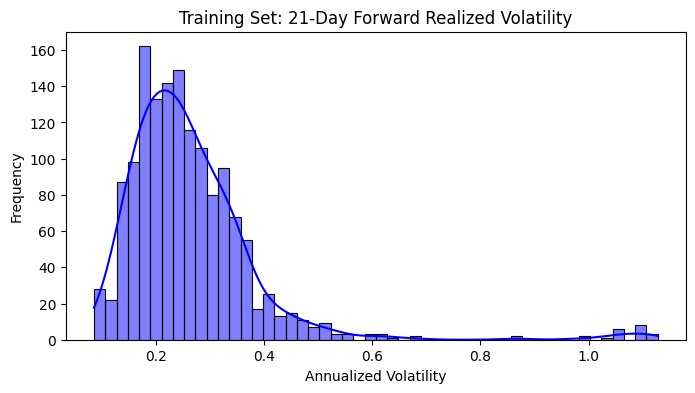


📊 Training Set Volatility Correlations:
                  vol_rolling_21d  vol_garman_klass  target_vol_21d
vol_rolling_21d          1.000000          0.942296        0.472222
vol_garman_klass         0.942296          1.000000        0.485905
target_vol_21d           0.472222          0.485905        1.000000


In [61]:
print("\n🔍 Running EDA on Training Set Only...")

# Target Distribution
plt.figure(figsize=(8, 4))
sns.histplot(y_train, bins=50, kde=True, color='blue')
plt.title("Training Set: 21-Day Forward Realized Volatility")
plt.xlabel("Annualized Volatility")
plt.ylabel("Frequency")
plt.show()

# Quick Correlation Check on Top Volatility Features
vol_cols = ['vol_rolling_21d', 'vol_garman_klass', 'target_vol_21d']
if all(col in train_df.columns for col in vol_cols):
    print("\n📊 Training Set Volatility Correlations:")
    print(train_df[vol_cols].corr())

🧠 Training Baseline LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000403 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Number of data points in the train set: 1475, number of used features: 30
[LightGBM] [Info] Start training from score 0.264660
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 15 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

<Figure size 1000x800 with 0 Axes>

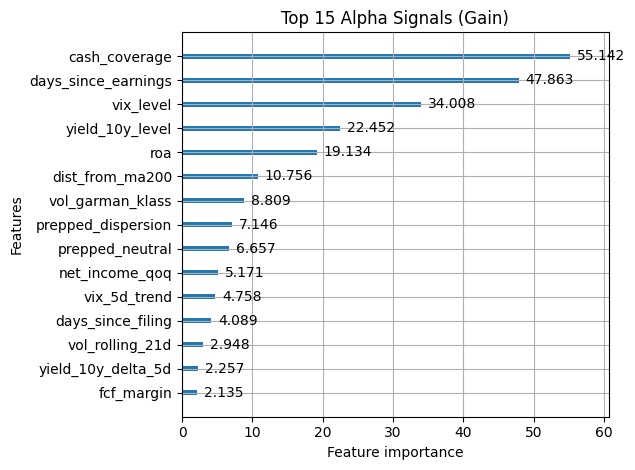

In [73]:
import lightgbm as lgb
import matplotlib.pyplot as plt

print("🧠 Training Baseline LightGBM...")
model = lgb.LGBMRegressor(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=42, 
    n_jobs=-1
)

# Train the model with early stopping to prevent overfitting
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=15)]
)

# Generate the Feature Importance Plot
plt.figure(figsize=(10, 8))
lgb.plot_importance(
    model, 
    max_num_features=15, 
    importance_type='gain', 
    title='Top 15 Alpha Signals (Gain)'
)
plt.tight_layout()
plt.show()

In [85]:
# EDA on train_df

print("📊 Dataset Overview:")
print(f"Shape: {train_df.shape}")
print(f"Columns: {len(train_df.columns)}")
print("\nData Types:")
print(train_df.dtypes.value_counts())
print("\nFirst 5 rows:")
display(train_df.head())

print("\nMissing Values Summary:")
missing = train_df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing)
else:
    print("No missing values found.")

print("\nSummary Statistics for Numerical Features:")
display(train_df.select_dtypes(include=[np.number]).describe())

📊 Dataset Overview:
Shape: (1475, 33)
Columns: 33

Data Types:
float64           32
datetime64[us]     1
Name: count, dtype: int64

First 5 rows:


,trading_date,msft_return,roa,cash_coverage,debt_to_asset,fcf_margin,net_income_qoq,sec_sentiment,sec_neutral,sec_dispersion,...,vix_5d_trend,yield_10y_level,yield_10y_delta_5d,vol_rolling_21d,qqq_vol_21d,vol_garman_klass,vol_surge,amihud_ratio,dist_from_ma200,target_vol_21d
0,2019-05-01,-0.020827,0.033459,0.080277,0.639685,0.358346,0.0462,-0.36476,0.310013,0.567182,...,1.66,2.511,-0.011,0.159189,0.068876,0.111036,1.288354,0.000006,0.167499,0.219038
1,2019-05-02,-0.013059,0.033459,0.080277,0.639685,0.358346,0.0462,-0.36476,0.310013,0.567182,...,1.17,2.552,0.018,0.169133,0.071590,0.114913,1.286641,0.000004,0.151066,0.239126
2,2019-05-03,0.021314,0.033459,0.080277,0.639685,0.358346,0.0462,-0.36476,0.310013,0.567182,...,0.14,2.531,0.026,0.180620,0.086565,0.116328,1.166540,0.000007,0.174300,0.247900
3,2019-05-06,-0.005819,0.033459,0.080277,0.639685,0.358346,0.0462,-0.36476,0.310013,0.567182,...,2.33,2.500,-0.036,0.181076,0.090641,0.116537,1.124753,0.000002,0.166175,0.260375
4,2019-05-07,-0.020523,0.033459,0.080277,0.639685,0.358346,0.0462,-0.36476,0.310013,0.567182,...,6.20,2.448,-0.061,0.199108,0.115292,0.125330,1.599882,0.000005,0.141079,0.255666



Missing Values Summary:
No missing values found.

Summary Statistics for Numerical Features:


,msft_return,roa,cash_coverage,debt_to_asset,fcf_margin,net_income_qoq,sec_sentiment,sec_neutral,sec_dispersion,prepped_sentiment,...,vix_5d_trend,yield_10y_level,yield_10y_delta_5d,vol_rolling_21d,qqq_vol_21d,vol_garman_klass,vol_surge,amihud_ratio,dist_from_ma200,target_vol_21d
count,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,...,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1.475000e+03,1475.000000,1475.000000
mean,0.000939,0.045684,0.109516,0.544177,0.312700,0.052356,-0.417528,0.306385,0.524432,0.404392,...,0.041966,2.654136,0.005977,0.263948,0.218473,0.196487,1.006614,1.833230e-06,0.099144,0.264660
std,0.018456,0.006381,0.028367,0.056816,0.093694,0.094852,0.051937,0.024884,0.047996,0.081450,...,4.033335,1.358795,0.132644,0.132354,0.114370,0.075424,0.328764,1.556982e-06,0.110830,0.132364
min,-0.147390,0.033459,0.061588,0.433047,0.092877,-0.108553,-0.525168,0.261646,0.436864,0.283918,...,-21.100002,0.499000,-0.589000,0.085838,0.067319,0.094453,0.304568,0.000000e+00,-0.207804,0.085838
25%,-0.007998,0.041193,0.080277,0.497641,0.293619,-0.000388,-0.441911,0.292812,0.492685,0.344729,...,-1.600001,1.517000,-0.066000,0.186677,0.150077,0.150167,0.796627,6.434226e-07,0.019554,0.187017
50%,0.001101,0.046477,0.118410,0.543520,0.352271,0.046200,-0.409969,0.300320,0.529312,0.383939,...,-0.200000,2.531000,0.005000,0.240503,0.191551,0.176921,0.926343,1.457103e-06,0.129418,0.242175
75%,0.010700,0.049308,0.135882,0.598874,0.366235,0.113007,-0.388530,0.325403,0.553656,0.471877,...,1.434999,3.980500,0.086500,0.310003,0.264500,0.228060,1.132055,2.589105e-06,0.177621,0.310200
max,0.142169,0.061133,0.152635,0.639685,0.413311,0.245899,-0.263342,0.362238,0.635401,0.540660,...,35.850002,4.988000,0.511000,1.127596,0.917289,0.674622,2.998862,1.303430e-05,0.326962,1.127596



📈 Feature Distributions:


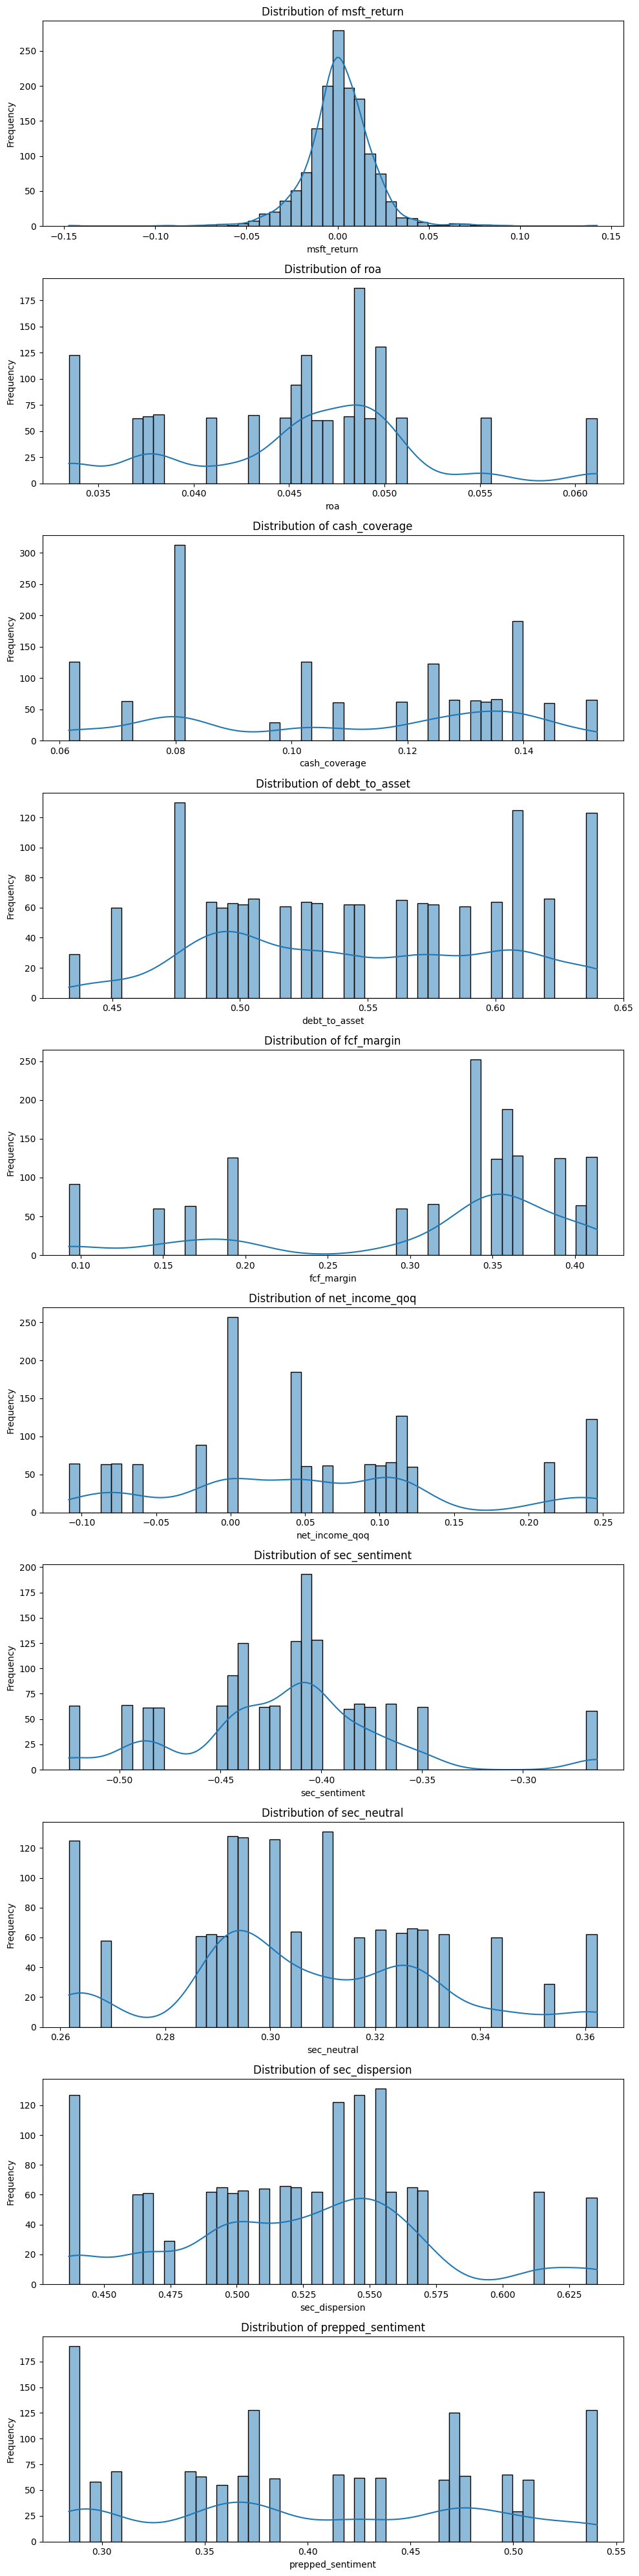

In [86]:
# Feature Distributions
print("\n📈 Feature Distributions:")

# Select numerical features (excluding date if present)
num_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
if 'trading_date' in num_features:
    num_features.remove('trading_date')

# Plot histograms for key features (limit to avoid too many plots)
key_features = num_features[:10]  # First 10 numerical features
if target in key_features:
    key_features.remove(target)
    key_features.insert(0, target)  # Put target first

fig, axes = plt.subplots(len(key_features), 1, figsize=(10, 4*len(key_features)))
if len(key_features) == 1:
    axes = [axes]

for i, col in enumerate(key_features):
    sns.histplot(train_df[col], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


🔗 Correlation Matrix:


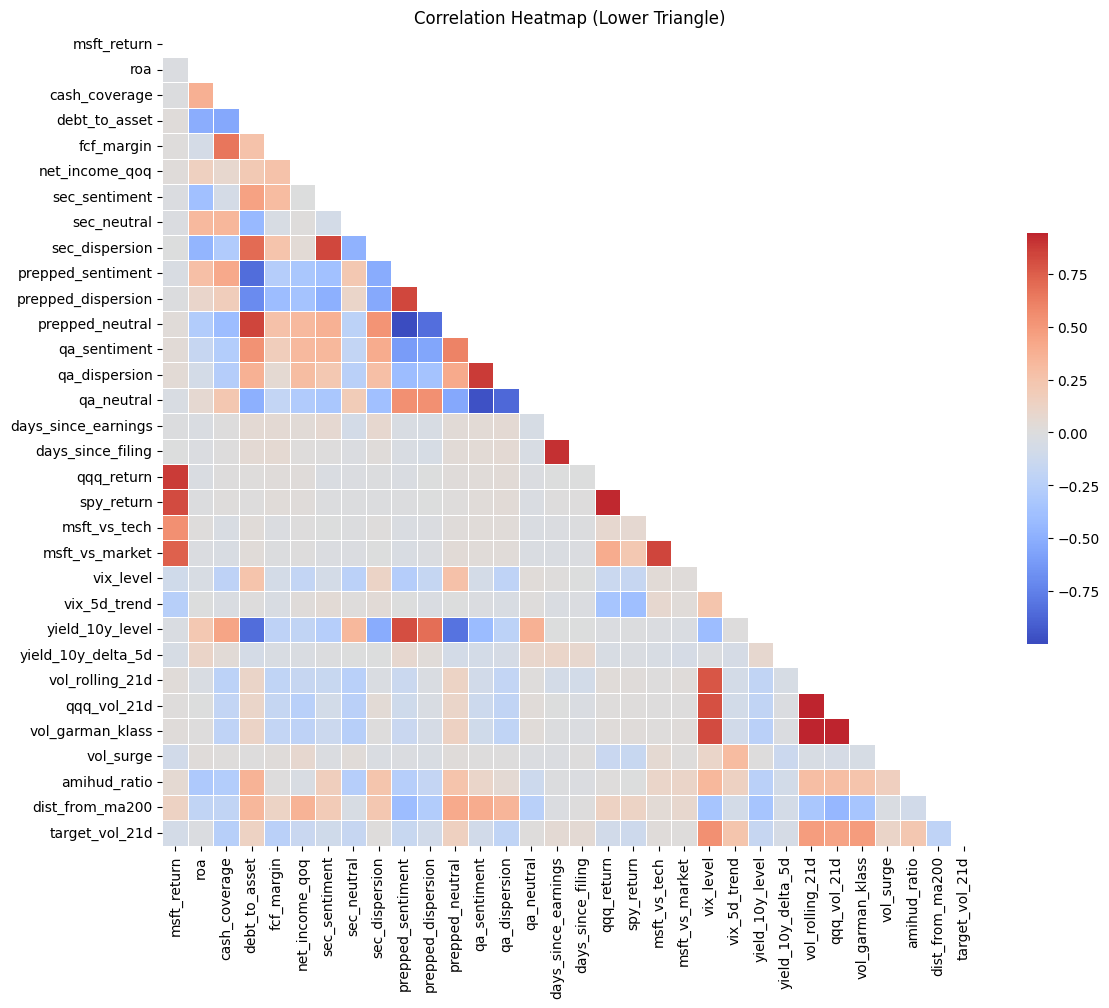


Top 10 correlations with target_vol_21d:
target_vol_21d      1.000000
vix_level           0.544720
vol_garman_klass    0.485905
vol_rolling_21d     0.472222
qqq_vol_21d         0.447491
cash_coverage       0.255378
vix_5d_trend        0.246257
fcf_margin          0.235840
amihud_ratio        0.230910
dist_from_ma200     0.208747
qa_dispersion       0.201056
Name: target_vol_21d, dtype: float64


In [87]:
# Correlation Analysis
print("\n🔗 Correlation Matrix:")

# Compute correlation matrix for numerical features
corr_matrix = train_df.select_dtypes(include=[np.number]).corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlation Heatmap (Lower Triangle)')
plt.tight_layout()
plt.show()

# Top correlations with target
if target in corr_matrix.columns:
    target_corr = corr_matrix[target].abs().sort_values(ascending=False)
    print(f"\nTop 10 correlations with {target}:")
    print(target_corr.head(11))  # +1 for itself


🔍 Outlier Detection:


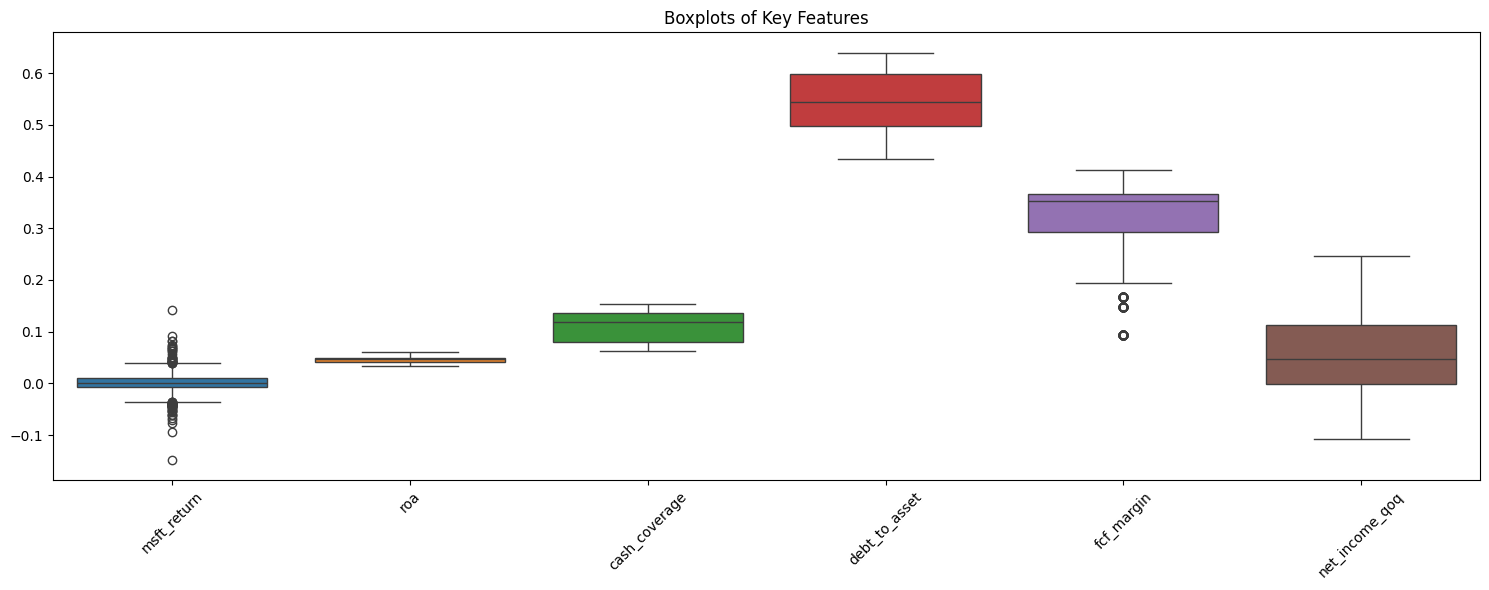


Outlier Summary (IQR method):
msft_return: 70 outliers (4.7%)
roa: 0 outliers (0.0%)
cash_coverage: 0 outliers (0.0%)
debt_to_asset: 0 outliers (0.0%)
fcf_margin: 215 outliers (14.6%)


In [88]:
# Outlier Analysis
print("\n🔍 Outlier Detection:")

# Boxplots for key features
plt.figure(figsize=(15, 6))
key_features_for_box = key_features[:6]  # Limit to 6 features
sns.boxplot(data=train_df[key_features_for_box])
plt.title('Boxplots of Key Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Check for extreme outliers using IQR
def detect_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return len(outliers), len(outliers)/len(data)*100

print("\nOutlier Summary (IQR method):")
for col in key_features[:5]:  # Check first 5 key features
    count, pct = detect_outliers_iqr(train_df, col)
    print(f"{col}: {count} outliers ({pct:.1f}%)")

In [109]:
train_df.columns

Index(['trading_date', 'msft_return', 'roa', 'cash_coverage', 'debt_to_asset',
       'fcf_margin', 'net_income_qoq', 'sec_sentiment', 'sec_neutral',
       'sec_dispersion', 'prepped_sentiment', 'prepped_dispersion',
       'prepped_neutral', 'qa_sentiment', 'qa_dispersion', 'qa_neutral',
       'days_since_earnings', 'days_since_filing', 'qqq_return', 'spy_return',
       'msft_vs_tech', 'msft_vs_market', 'vix_level', 'vix_5d_trend',
       'yield_10y_level', 'yield_10y_delta_5d', 'vol_rolling_21d',
       'qqq_vol_21d', 'vol_garman_klass', 'vol_surge', 'amihud_ratio',
       'dist_from_ma200', 'target_vol_21d'],
      dtype='str')

In [112]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

INPUT_FILE = "df_features.csv"
OUTDIR = "./output"
os.makedirs(OUTDIR, exist_ok=True)

# =========================
# Load + basic prep
# =========================
df_eda = train_df.copy()

if "trading_date" in df_eda.columns:
    df_eda["trading_date"] = pd.to_datetime(df_eda["trading_date"], errors="coerce")
    df_eda = df_eda.sort_values("trading_date")

TARGET = "target_vol_21d"
num_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()

# =========================
# Helper functions
# =========================
def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, name), dpi=180, bbox_inches="tight")
    plt.close()

def safe_qcut(series, q=3, labels=None):
    s = pd.to_numeric(series, errors="coerce")
    valid = s.dropna()
    if valid.nunique() < q:
        return pd.Series(pd.Categorical([np.nan] * len(series)), index=series.index)
    try:
        return pd.qcut(s, q=q, labels=labels, duplicates="drop")
    except Exception:
        return pd.Series(pd.Categorical([np.nan] * len(series)), index=series.index)

def add_quantile_bucket(df, col, q=3, labels=None):
    if col in df.columns:
        df[f"{col}_bucket"] = safe_qcut(df[col], q=q, labels=labels)
    return df

def add_days_bucket(df, col):
    if col in df.columns:
        bins = [-1, 5, 20, 60, np.inf]
        labels = ["0-5", "6-20", "21-60", "61+"]
        df[f"{col}_bucket"] = pd.cut(df[col], bins=bins, labels=labels)
    return df

def make_bucket_table(df, bucket_col, target=TARGET):
    tmp = df[[bucket_col, target]].dropna().copy()
    out = tmp.groupby(bucket_col, observed=False)[target].agg(
        ["count", "mean", "median", "std", "min", "max"]
    ).reset_index()
    return out

def save_bucket_artifacts(df, bucket_col, target=TARGET):
    tmp = df[[bucket_col, target]].dropna().copy()
    if tmp.empty:
        return

    stats = make_bucket_table(df, bucket_col, target)
    stats.to_csv(os.path.join(OUTDIR, f"{bucket_col}_target_stats.csv"), index=False)

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=tmp, x=bucket_col, y=target, color="#7aa6d1")
    plt.title(f"{target} by {bucket_col}")
    savefig(f"box_{bucket_col}.png")

    plt.figure(figsize=(10, 5))
    sns.violinplot(data=tmp, x=bucket_col, y=target, color="#f0a35e")
    plt.title(f"{target} distribution by {bucket_col}")
    savefig(f"violin_{bucket_col}.png")

    plt.figure(figsize=(8,4))
    sns.barplot(data=stats, x=bucket_col, y="mean", color="#59a14f")
    plt.title(f"Average {target} by {bucket_col}")
    plt.ylabel(f"mean {target}")
    savefig(f"barmean_{bucket_col}.png")

def save_heatmap(df, row_bucket, col_bucket, target=TARGET):
    tmp = df[[row_bucket, col_bucket, target]].dropna().copy()
    if tmp.empty:
        return

    pivot_mean = tmp.pivot_table(index=row_bucket, columns=col_bucket, values=target, aggfunc="mean")
    pivot_count = tmp.pivot_table(index=row_bucket, columns=col_bucket, values=target, aggfunc="count")

    pivot_mean.to_csv(os.path.join(OUTDIR, f"heatmap_mean_{row_bucket}_x_{col_bucket}.csv"))
    pivot_count.to_csv(os.path.join(OUTDIR, f"heatmap_count_{row_bucket}_x_{col_bucket}.csv"))

    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_mean, annot=True, fmt=".3f", cmap="YlOrRd")
    plt.title(f"Mean {target}: {row_bucket} x {col_bucket}")
    savefig(f"heatmap_mean_{row_bucket}_x_{col_bucket}.png")

    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_count, annot=True, fmt=".0f", cmap="Blues")
    plt.title(f"Observation Count: {row_bucket} x {col_bucket}")
    savefig(f"heatmap_count_{row_bucket}_x_{col_bucket}.png")

def facet_boxplot(df, xcol, huecol, filename):
    tmp = df[[xcol, huecol, TARGET]].dropna().copy()
    if tmp.empty:
        return
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=tmp, x=xcol, y=TARGET, hue=huecol)
    plt.title(f"{TARGET} by {xcol} and {huecol}")
    plt.legend(title=huecol, bbox_to_anchor=(1.02, 1), loc="upper left")
    savefig(filename)

# =========================
# Base EDA tables
# =========================
missing = (
    df_eda.isna().mean()
    .sort_values(ascending=False)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "column"})
)
missing["missing_count"] = df_eda.isna().sum().values
missing["dtype"] = missing["column"].map(df_eda.dtypes.astype(str))
missing.to_csv(os.path.join(OUTDIR, "missingness_summary.csv"), index=False)

summary = df_eda[num_cols].describe().T
summary["missing_pct"] = df_eda[num_cols].isna().mean()
summary["skew"] = df_eda[num_cols].skew(numeric_only=True)
summary["kurtosis"] = df_eda[num_cols].kurt(numeric_only=True)
summary.to_csv(os.path.join(OUTDIR, "numeric_summary.csv"))

corr_target = df_eda[num_cols].corr(numeric_only=True)[TARGET].sort_values(ascending=False)
corr_target.to_csv(os.path.join(OUTDIR, "correlation_with_target.csv"))

# =========================
# Basic plots
# =========================
plt.figure(figsize=(12, 8))
miss20 = missing.head(20).sort_values("missing_pct")
plt.barh(miss20["column"], miss20["missing_pct"], color="#4C78A8")
plt.title("Top 20 Columns by Missingness")
plt.xlabel("Missing Fraction")
plt.xlim(0, 1)
savefig("missingness_top20.png")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_eda[TARGET].dropna(), bins=40, kde=True, ax=axes[0], color="#F58518")
axes[0].set_title("Target Distribution: 21-Day Forward Volatility")
sns.boxplot(x=df_eda[TARGET], ax=axes[1], color="#F58518")
axes[1].set_title("Target Boxplot")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "target_distribution.png"), dpi=180, bbox_inches="tight")
plt.close()

if "trading_date" in df_eda.columns:
    plt.figure(figsize=(14, 5))
    plt.plot(df_eda["trading_date"], df_eda[TARGET], color="#54A24B", linewidth=1)
    plt.title("21-Day Forward Volatility Over Time")
    plt.xlabel("Date")
    plt.ylabel(TARGET)
    savefig("target_timeseries.png")

    plt.figure(figsize=(14, 5))
    roll = df_eda[TARGET].rolling(21, min_periods=10).mean()
    plt.plot(df_eda["trading_date"], df_eda[TARGET], color="lightgray", linewidth=0.8, label="Daily")
    plt.plot(df_eda["trading_date"], roll, color="#4C78A8", linewidth=2, label="21D Rolling Mean")
    plt.title("Target Volatility with 21-Day Rolling Mean")
    plt.legend()
    savefig("target_rolling_mean.png")

key_features = [
    c for c in [
        TARGET,
        "vix_level",
        "vol_rolling_21d",
        "qqq_vol_21d",
        "vol_garman_klass",
        "vol_surge",
        "msft_return",
        "qqq_return",
        "spy_return",
        "dist_from_ma200",
        "yield_10y_level",
        "yield_10y_delta_5d",
        "sec_sentiment",
        "sec_neutral",
        "sec_dispersion",
        "prepped_sentiment",
        "prepped_neutral",
        "prepped_dispersion",
        "qa_sentiment",
        "qa_neutral",
        "qa_dispersion",
        "days_since_earnings",
        "days_since_filing",
        "amihud_ratio",
        "msft_vs_tech",
        "msft_vs_market",
    ] if c in df_eda.columns
]

if len(key_features) > 1:
    corr = df_eda[key_features].corr(numeric_only=True)
    plt.figure(figsize=(14, 11))
    sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title("Correlation Heatmap: Key Features")
    savefig("correlation_heatmap_key_features.png")

scatter_feats = [c for c in [
    "vix_level",
    "vol_rolling_21d",
    "qqq_vol_21d",
    "vol_garman_klass",
    "dist_from_ma200",
    "sec_sentiment",
    "qa_sentiment",
    "prepped_sentiment"
] if c in df_eda.columns]

if scatter_feats:
    rows = int(np.ceil(len(scatter_feats) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for i, feat in enumerate(scatter_feats):
        sns.regplot(
            data=df_eda,
            x=feat,
            y=TARGET,
            ax=axes[i],
            scatter_kws={"s": 10, "alpha": 0.35},
            line_kws={"color": "red"},
        )
        axes[i].set_title(f"{feat} vs {TARGET}")
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "scatter_regplots_vs_target.png"), dpi=180, bbox_inches="tight")
    plt.close()

sent_feats = [c for c in ["sec_sentiment", "prepped_sentiment", "qa_sentiment"] if c in df_eda.columns]
if sent_feats and "trading_date" in df_eda.columns:
    plt.figure(figsize=(14, 5))
    colors = ["#4C78A8", "#F58518", "#E45756"]
    for feat, color in zip(sent_feats, colors):
        plt.plot(df_eda["trading_date"], df_eda[feat], label=feat, linewidth=1, alpha=0.9, color=color)
    plt.title("Sentiment Features Over Time")
    plt.xlabel("Date")
    plt.legend()
    savefig("sentiment_timeseries.png")

# =========================
# Buckets / categories
# =========================
for col in [
    "vix_level",
    "vol_rolling_21d",
    "qqq_vol_21d",
    "vol_garman_klass",
    "sec_sentiment",
    "qa_sentiment",
    "sec_dispersion",
    "qa_dispersion",
    "amihud_ratio",
    "dist_from_ma200",
    "prepped_sentiment"
]:
    df_eda = add_quantile_bucket(df_eda, col, q=3, labels=["Low", "Medium", "High"])

for col in ["days_since_earnings", "days_since_filing"]:
    df_eda = add_days_bucket(df_eda, col)

if "msft_return" in df_eda.columns:
    bins = [-np.inf, -0.01, 0.01, np.inf]
    labels = ["Down", "Flat", "Up"]
    df_eda["msft_return_bucket"] = pd.cut(df_eda["msft_return"], bins=bins, labels=labels)

if "qqq_return" in df_eda.columns:
    bins = [-np.inf, -0.01, 0.01, np.inf]
    labels = ["Down", "Flat", "Up"]
    df_eda["qqq_return_bucket"] = pd.cut(df_eda["qqq_return"], bins=bins, labels=labels)

bucket_cols = [c for c in df_eda.columns if c.endswith("_bucket")]
df_eda.to_csv(os.path.join(OUTDIR, "df_with_buckets.csv"), index=False)

# =========================
# Target variation by category
# =========================
for bucket_col in bucket_cols:
    save_bucket_artifacts(df_eda, bucket_col, TARGET)

# =========================
# Interaction heatmaps
# =========================
interaction_pairs = [
    ("vix_level_bucket", "sec_sentiment_bucket"),
    ("vix_level_bucket", "qa_sentiment_bucket"),
    ("vix_level_bucket", "days_since_earnings_bucket"),
    ("vol_rolling_21d_bucket", "sec_sentiment_bucket"),
    ("qqq_vol_21d_bucket", "days_since_earnings_bucket"),
    ("msft_return_bucket", "vix_level_bucket"),
    ("qqq_return_bucket", "vix_level_bucket"),
    ("days_since_earnings_bucket", "sec_sentiment_bucket"),
    ("days_since_filing_bucket", "sec_sentiment_bucket"),
    ("sec_dispersion_bucket", "vix_level_bucket"),
    ("qa_dispersion_bucket", "vix_level_bucket")
    
]

for row_bucket, col_bucket in interaction_pairs:
    if row_bucket in df_eda.columns and col_bucket in df_eda.columns:
        save_heatmap(df_eda, row_bucket, col_bucket, TARGET)

# =========================
# Faceted boxplots
# =========================
facet_specs = [
    ("days_since_earnings_bucket", "vix_level_bucket", "facet_days_since_earnings_x_vix.png"),
    ("sec_sentiment_bucket", "vix_level_bucket", "facet_sec_sentiment_x_vix.png"),
    ("qa_sentiment_bucket", "vix_level_bucket", "facet_qa_sentiment_x_vix.png"),
    ("msft_return_bucket", "vix_level_bucket", "facet_msft_return_x_vix.png"),
]

for xcol, huecol, fname in facet_specs:
    if xcol in df_eda.columns and huecol in df_eda.columns:
        facet_boxplot(df_eda, xcol, huecol, fname)

# =========================
# Pairplot of strongest features
# =========================
strong_feats = [
    c for c in [
        "target_vol_21d",
        "vix_level",
        "vol_rolling_21d",
        "qqq_vol_21d",
        "vol_garman_klass",
        "dist_from_ma200",
    ] if c in df_eda.columns
]

if len(strong_feats) >= 3:
    sample_base = df_eda[strong_feats].dropna()
    if len(sample_base) > 0:
        sample_df = sample_base.sample(min(600, len(sample_base)), random_state=42)
        pp = sns.pairplot(sample_df, corner=True, diag_kind="hist")
        pp.fig.suptitle("Pairplot of Strongest Quantitative Features", y=1.02)
        pp.savefig(os.path.join(OUTDIR, "pairplot_strong_features.png"), dpi=180, bbox_inches="tight")
        plt.close("all")

# =========================
# README
# =========================
notes = []
notes.append("Master EDA outputs generated for df_features.csv")
notes.append(f"Rows: {len(df_eda):,}")
notes.append(f"Columns: {df_eda.shape[1]:,}")
notes.append("Important files:")
notes.append("- correlation_with_target.csv")
notes.append("- numeric_summary.csv")
notes.append("- missingness_summary.csv")
notes.append("- df_with_buckets.csv")
notes.append("- heatmap_mean_*.csv and .png for interaction analysis")
notes.append("- box_*, violin_*, barmean_* for bucket-based target variation")

with open(os.path.join(OUTDIR, "README.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(notes))

print("Master EDA complete. Outputs saved to:", OUTDIR)
print("Created bucket columns:", bucket_cols)
print("Top positive correlations with target:")
print(corr_target.head(10))
print("Top negative correlations with target:")
print(corr_target.tail(10))

Master EDA complete. Outputs saved to: ./output
Created bucket columns: ['vix_level_bucket', 'vol_rolling_21d_bucket', 'qqq_vol_21d_bucket', 'vol_garman_klass_bucket', 'sec_sentiment_bucket', 'qa_sentiment_bucket', 'sec_dispersion_bucket', 'qa_dispersion_bucket', 'amihud_ratio_bucket', 'dist_from_ma200_bucket', 'prepped_sentiment_bucket', 'days_since_earnings_bucket', 'days_since_filing_bucket', 'msft_return_bucket', 'qqq_return_bucket']
Top positive correlations with target:
target_vol_21d      1.000000
vix_level           0.544720
vol_garman_klass    0.485905
vol_rolling_21d     0.472222
qqq_vol_21d         0.447491
vix_5d_trend        0.246257
amihud_ratio        0.230910
prepped_neutral     0.151443
debt_to_asset       0.133999
vol_surge           0.110692
Name: target_vol_21d, dtype: float64
Top negative correlations with target:
sec_sentiment       -0.100758
spy_return          -0.112619
net_income_qoq      -0.144748
prepped_sentiment   -0.157192
sec_neutral         -0.160815
yie

In [ ]:
pd.read_csv('./output/prepped_sentiment.csv')

,vix_level_bucket,count,mean,median,std,min,max
0,Low,493,0.207700,0.189492,0.110810,0.085838,1.052274
1,Medium,490,0.241686,0.236418,0.077244,0.116058,1.049818
2,High,492,0.344616,0.319657,0.155433,0.114065,1.127596
